## Importing Files

In [1]:
import pandas as pd
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.insert(0, str(Path.cwd().parent))

data_dir = Path("..") / "data"
file_elec_consum = data_dir / 'Electricity consumption.csv'
file_weather = data_dir / 'Weather data.csv'
load = pd.read_csv(file_elec_consum)
weather = pd.read_csv(file_weather)

# **Baseline SARIMA to forecast electricity consumption**

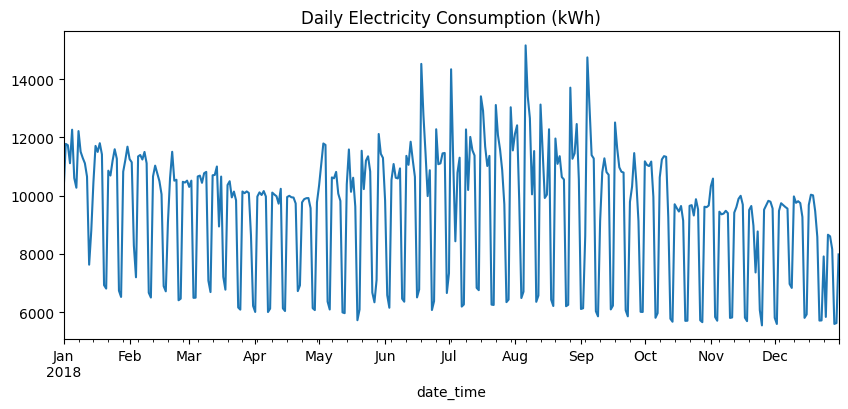

In [2]:

data = load.copy()
data["date_time"] = pd.to_datetime(data["date_time"])
data = data.set_index("date_time").sort_index()
df = data.loc[data.index.year == 2018]

df["energy_kWh"] = df["Electricity consumption (kW)"] * 0.25
monthly = df.resample("D").agg(
    consumption_kwh=("energy_kWh", "sum")
)

y = monthly["consumption_kwh"]

y.plot(figsize=(10,4), title="Daily Electricity Consumption (kWh)")
plt.show()

In [3]:
def adf_test(series):
    result = adfuller(series.dropna())
    return result[1]  # p-value

print("ADF p-value:", adf_test(y))

ADF p-value: 0.7842633654256308


In [4]:
y_diff = y.diff().dropna()
print("ADF p-value (diff):", adfuller(y_diff)[1])
y_seasonal_diff = y.diff(7).dropna()
print("ADF p-value (seasonal diff):", adfuller(y_seasonal_diff)[1])

ADF p-value (diff): 3.4823082793725054e-13
ADF p-value (seasonal diff): 2.8690961968709164e-10


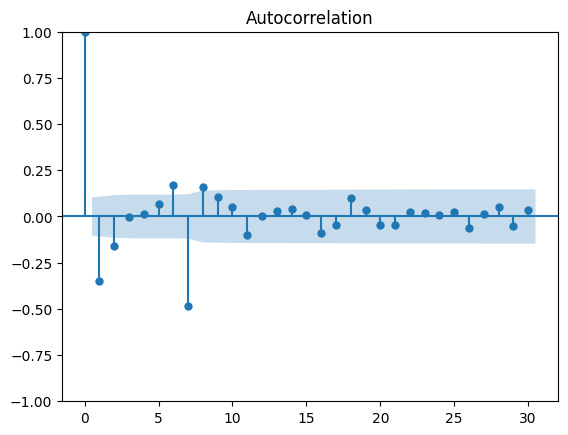

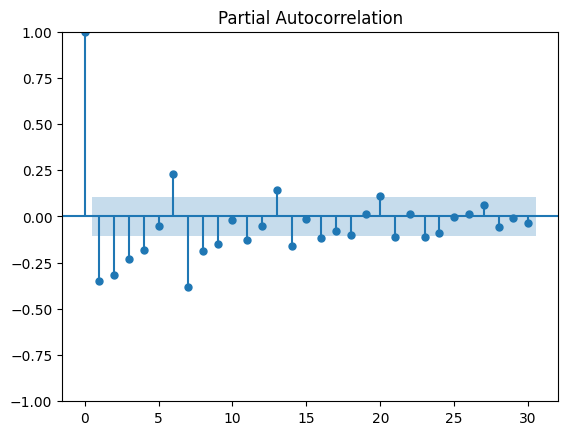

In [5]:
y_stationary = y.diff(1).diff(7).dropna()

plot_acf(y_stationary, lags=30)
plot_pacf(y_stationary, lags=30)
plt.show()

En observant les graphiques de la série doublement différenciée :

    Partie non-saisonnière (Lags courts 1-3) :

        ACF : On observe un pic significatif négatif au lag 1. Cela suggère un terme MA(1), donc q=1.

        PACF : On observe des pics significatifs aux lags 1, 2 et peut-être 3 qui s'estompent. Cela suggère un terme AR(1) ou AR(2), donc p=1 ou 2.

    Partie saisonnière (Lags multiples de s=7) :

        ACF : Un pic négatif très net au lag 7. C'est la signature d'un terme de moyenne mobile saisonnière, donc Q=1.

        PACF : Un pic net au lag 7 également, ce qui pourrait indiquer un terme P=1

## **Modeling**

In [6]:
final_model = SARIMAX(
    y,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit()
final_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                   consumption_kwh   No. Observations:                  365
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -2838.797
Date:                           Tue, 03 Mar 2026   AIC                           5685.593
Time:                                   09:59:20   BIC                           5701.002
Sample:                               01-01-2018   HQIC                          5691.728
                                    - 12-31-2018                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2222      0.037      5.995      0.000       0.150       0.295
ma.L1         -0.9458      0.022    -42.855      0.000      -0.989      -0.903
ma.S.L7       -0.7555      0.032    -23.504      0.000      -0.819      -0.693
sigma2      7.101e+05   2.66e+04     26.725      0.000    6.58e+05    7.62e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):               756.86
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               1.49   Skew:                            -0.41
Prob(H) (two-sided):                  0.03   Kurtosis:                        10.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## **Diagnostic**

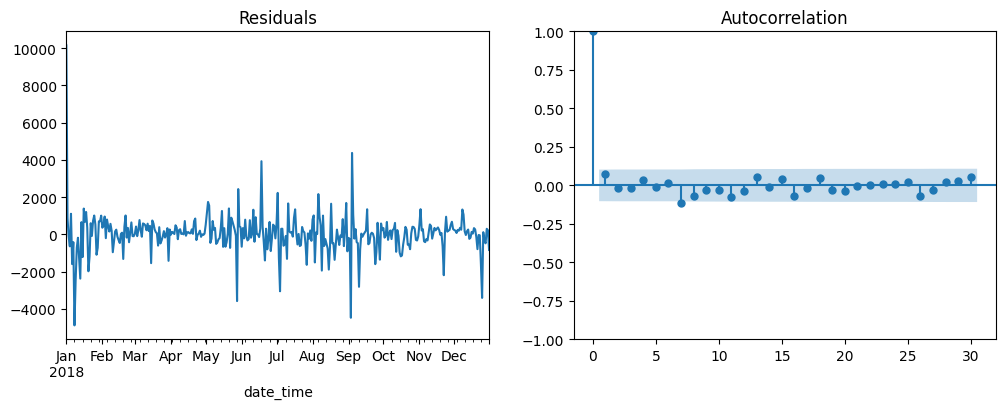

In [7]:
residuals = final_results.resid

fig, ax = plt.subplots(1,2, figsize=(12,4))
residuals.plot(title="Residuals", ax=ax[0])
plot_acf(residuals, lags=30, ax=ax[1])
plt.show()

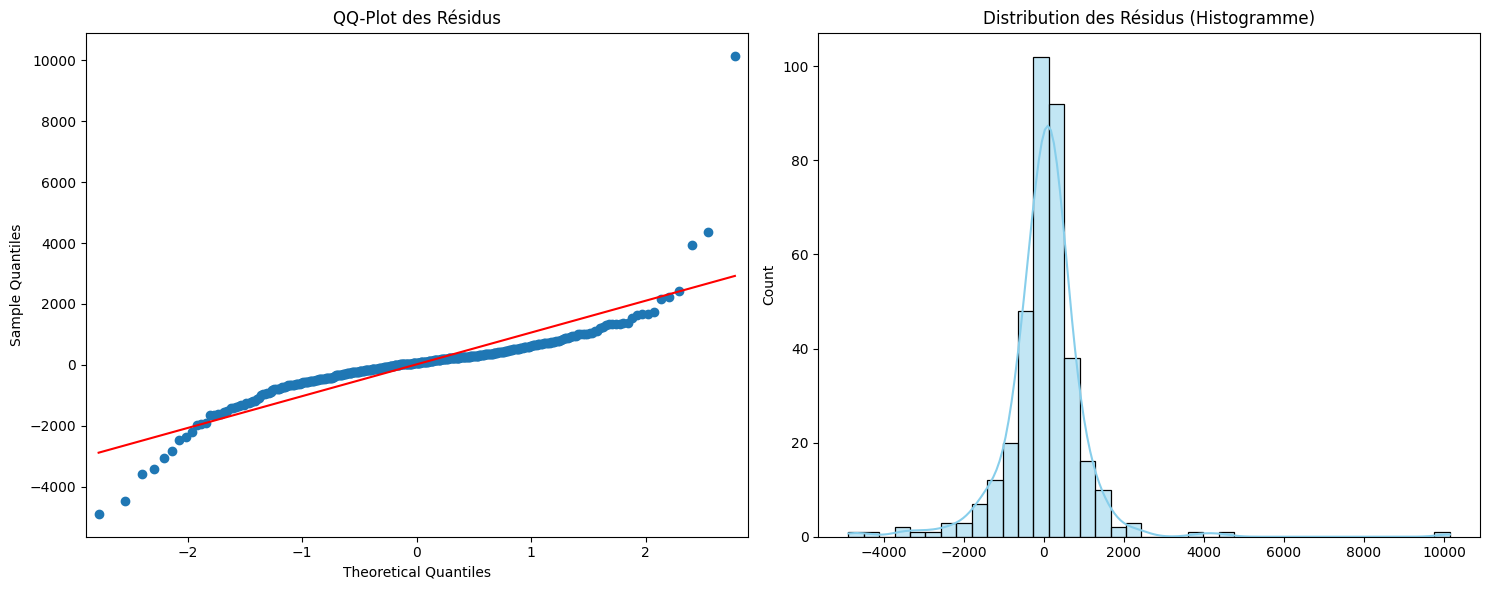

Test de Shapiro-Wilk: p-value = 0.0000


In [8]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.graphics.gofplots as smg
# Création d'une figure avec deux graphiques
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. QQ-Plot
smg.qqplot(residuals, line='s', ax=ax[0])
ax[0].set_title("QQ-Plot des Résidus")

# 2. Histogramme avec courbe de densité (KDE)
import seaborn as sns
sns.histplot(residuals, kde=True, ax=ax[1], color='skyblue')
ax[1].set_title("Distribution des Résidus (Histogramme)")

plt.tight_layout()
plt.show()

# Test statistique de Shapiro-Wilk (optionnel)
stat, p = stats.shapiro(residuals)
print(f'Test de Shapiro-Wilk: p-value = {p:.4f}')

In [9]:
df_2019 = data.loc[data.index.year == 2019]

df_2019["energy_kWh"] = df_2019["Electricity consumption (kW)"] * 0.25
monthly_2019 = df_2019.resample("D").agg(
    consumption_kwh=("energy_kWh", "sum")
)

y_2019 = monthly_2019["consumption_kwh"]

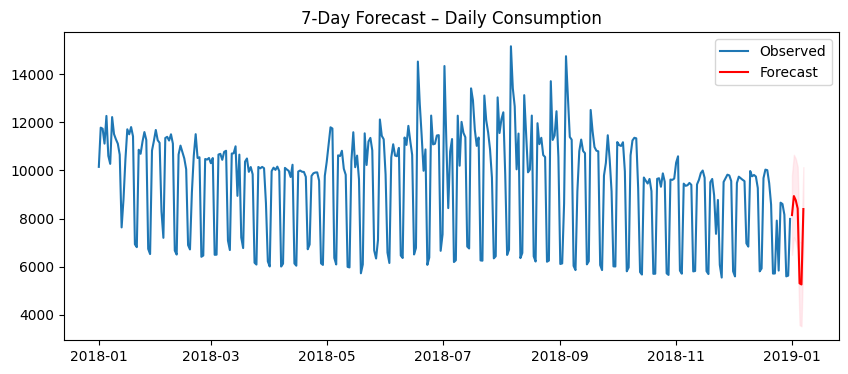

In [10]:
forecast = final_results.get_forecast(steps=7)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()
plt.figure(figsize=(10,4))
plt.plot(y, label="Observed")
plt.plot(forecast_mean, label="Forecast", color="red")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="pink", alpha=0.3
)
plt.legend()
plt.title("7-Day Forecast – Daily Consumption")
plt.show()

### **Performance**

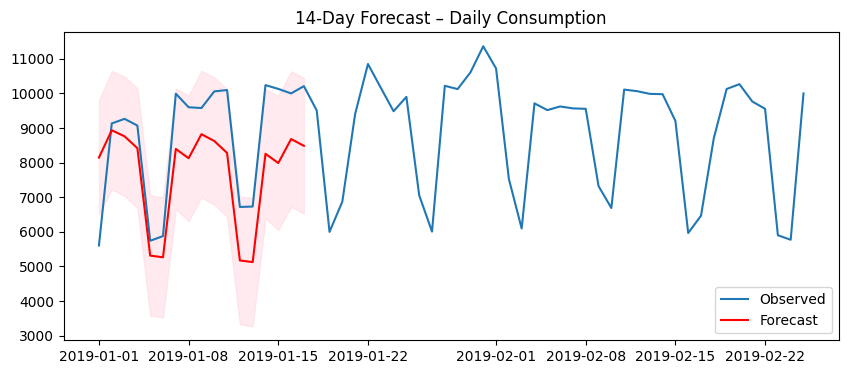

In [12]:
forecast = final_results.get_forecast(steps=17)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()
plt.figure(figsize=(10,4))
plt.plot(y_2019, label="Observed")
plt.plot(forecast_mean, label="Forecast", color="red")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="pink", alpha=0.3
)
plt.legend()
plt.title("14-Day Forecast – Daily Consumption")
plt.show()

In [11]:
import numpy as np

train = y
test = y_2019.iloc[:7]

model_bt = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 7)
)
results_bt = model_bt.fit(disp=False)

pred = results_bt.forecast(steps=7)

rmse = np.sqrt(mean_squared_error(test, pred))
mae = mean_absolute_error(test, pred)
mape = np.mean(np.abs((test - pred) / test)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 1091.38
MAE: 672.08
MAPE: 9.85%
